# Shepard's Interpolation (Inverse Distance Weighting)

## The Method

**Shepard's method** (1968) interpolates scattered data using inverse-distance weights. Given $m$ data points $(x_i, f_i)$ and a query point $x$, the interpolant is:

$$f^*(x) = \frac{\sum_{i=1}^m w_i(x)\, f_i}{\sum_{i=1}^m w_i(x)}, \quad w_i(x) = \|x - x_i\|^{-q}$$

where $q > 0$ is the **power parameter**.

## Properties

- **Interpolation**: $f^*(x_i) = f_i$ for all data points (by convention, with limit)
- **Positivity**: if all $f_i \geq 0$, then $f^*(x) \geq 0$
- **Partition of unity**: $\sum_i w_i / \sum_j w_j = 1$ — this is a convex combination
- **Effect of $q$**: small $q$ gives a smooth but strongly averaged result; large $q$ localizes the influence of each data point (Voronoi-like)
- **Flat spot problem**: at each $x_i$, the gradient $\nabla f^*$ is zero regardless of the data, creating unwanted "dimples" around the data points

## 2D Voronoi Connection

As $q \to \infty$, Shepard's method approaches **nearest-neighbor interpolation** (piecewise constant on Voronoi cells). At $q = 2$, the method is the classical **gravitational** inverse-square weighting.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

### Data setup and Shepard interpolation in 1D

We first illustrate in 1D how different power values $q$ shape the interpolant. The inverse distance weight concentrates around each data point as $q$ grows.

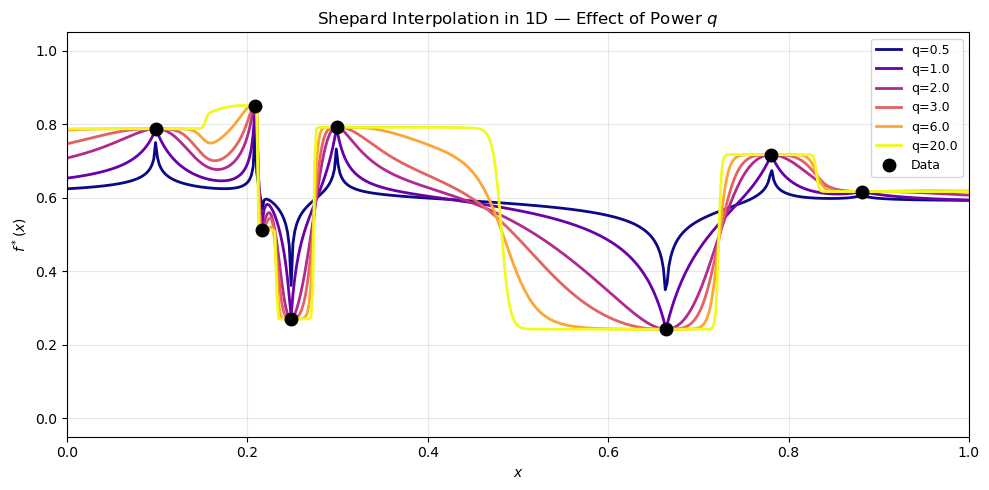

In [2]:
rng = np.random.default_rng(123)
m = 8
x_data = np.sort(rng.uniform(0.05, 0.95, m))
f_data = rng.uniform(0.05, 0.95, m)

x_eval = np.linspace(0, 1, 500)

def shepard_1d(x_eval, x_data, f_data, q):
    D = np.abs(x_eval[:, None] - x_data[None, :]) + 1e-12
    W = D ** (-q)
    return (W @ f_data) / W.sum(axis=1)

q_list = [0.5, 1.0, 2.0, 3.0, 6.0, 20.0]
colors = plt.cm.plasma(np.linspace(0, 1, len(q_list)))

fig, ax = plt.subplots(figsize=(10, 5))
for q, col in zip(q_list, colors):
    f_pred = shepard_1d(x_eval, x_data, f_data, q)
    ax.plot(x_eval, f_pred, color=col, lw=2, label=f'q={q}')
ax.plot(x_data, f_data, 'ko', ms=9, zorder=5, label='Data')
ax.set_xlabel('$x$'); ax.set_ylabel('$f^*(x)$')
ax.set_title('Shepard Interpolation in 1D — Effect of Power $q$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.savefig('shepard_1d.png', dpi=100, bbox_inches='tight'); plt.show()

### 2D Shepard interpolation

In 2D, the interpolant creates smooth surfaces between data points. The power $q$ controls the localization:
- $q < 1$: global averaging, very flat
- $q = 2$: inverse-square — the classical gravitational potential weighting
- $q \gg 1$: Voronoi-like piecewise constant

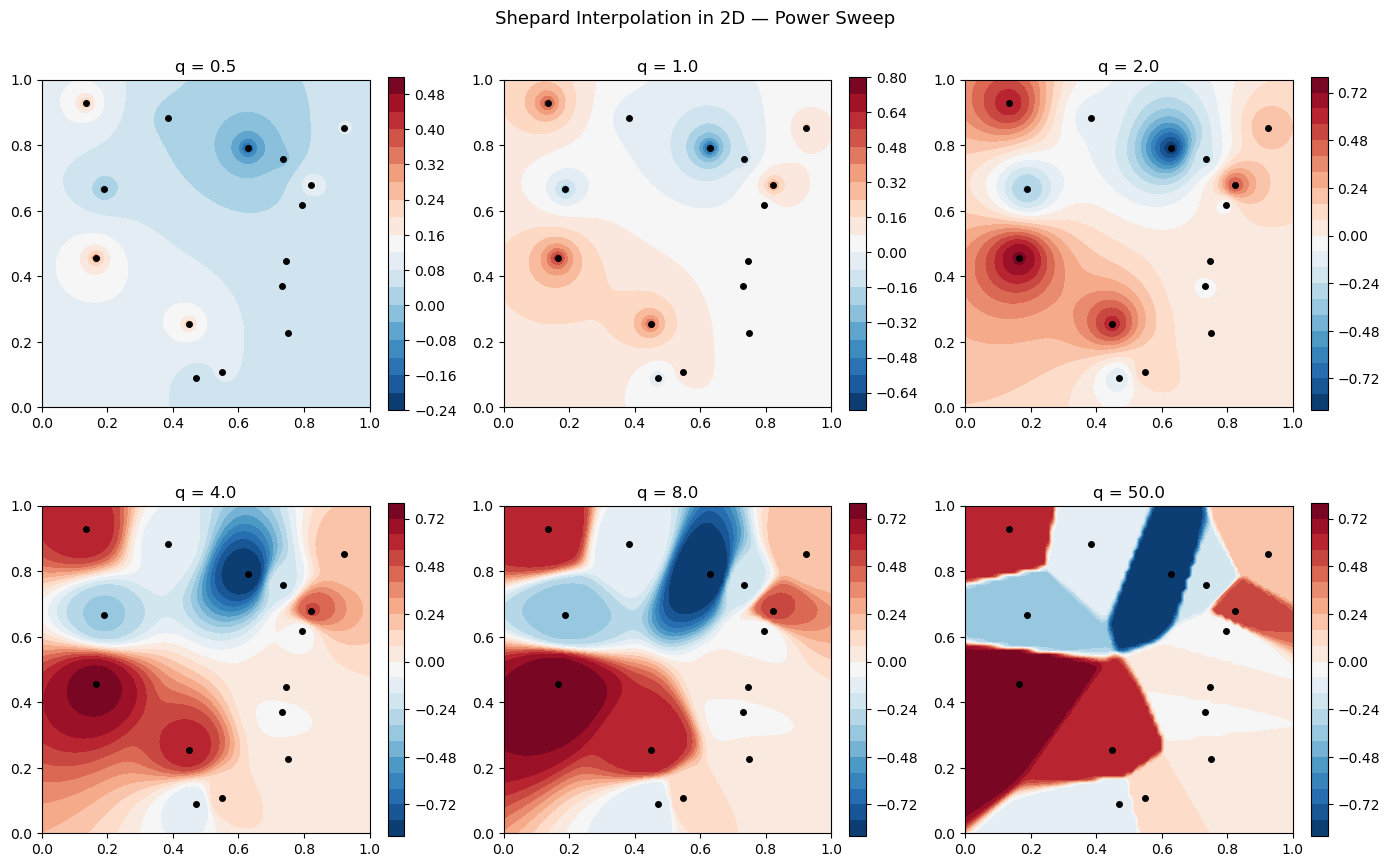

In [3]:
rng2 = np.random.default_rng(42)
m2 = 15
pts = rng2.uniform(0.05, 0.95, (m2, 2))
vals = np.sin(4*np.pi*pts[:,0]) * np.cos(4*np.pi*pts[:,1])

g = 80
gx = np.linspace(0, 1, g)
Yg, Xg = np.meshgrid(gx, gx)
grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])

def shepard_2d(grid_pts, pts, vals, q):
    diff = grid_pts[:, None, :] - pts[None, :, :]  # (G, m, 2)
    D = np.sqrt(np.sum(diff**2, axis=-1)) + 1e-12   # (G, m)
    W = D ** (-q)
    return (W @ vals) / W.sum(axis=1)

q_list_2d = [0.5, 1.0, 2.0, 4.0, 8.0, 50.0]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, q in zip(axes.ravel(), q_list_2d):
    f_grid = shepard_2d(grid_pts, pts, vals, q).reshape(g, g)
    im = ax.contourf(Xg, Yg, f_grid, levels=20, cmap='RdBu_r')
    ax.plot(pts[:,0], pts[:,1], 'k.', ms=8)
    ax.set_title(f'q = {q}'); ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Shepard Interpolation in 2D — Power Sweep', fontsize=13)
plt.tight_layout(); plt.savefig('shepard_2d.png', dpi=100, bbox_inches='tight'); plt.show()

### The flat spot (zero-gradient) problem

A key limitation of Shepard's method is that $\nabla f^*(x_i) = 0$ for every data point $x_i$, regardless of the surrounding data. This creates "flat plateau" artifacts around observations. We visualize the gradient magnitude to expose this.

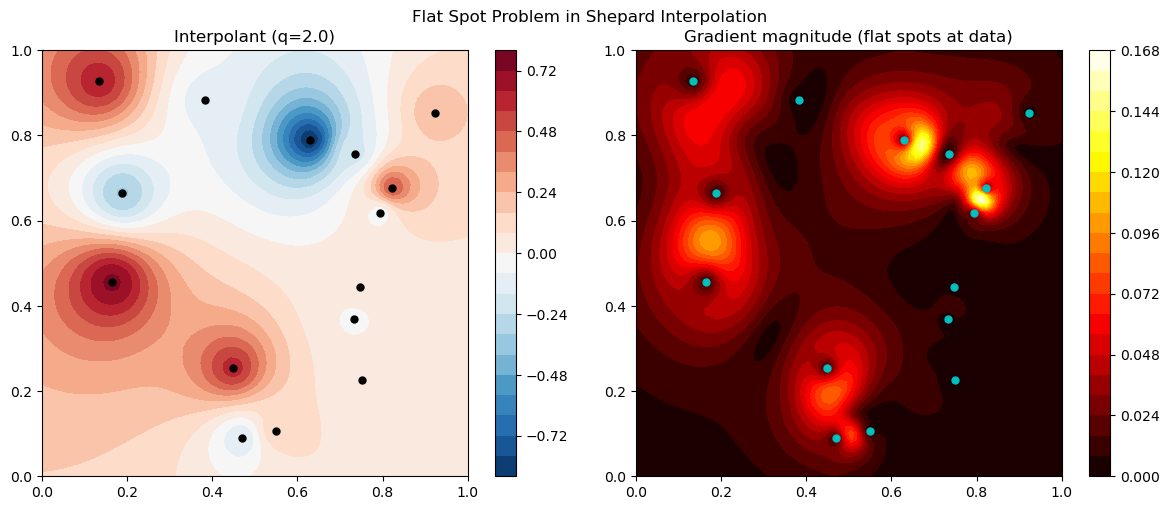

In [4]:
q_fs = 2.0
f_grid_fs = shepard_2d(grid_pts, pts, vals, q_fs).reshape(g, g)
# Numerical gradient
gy_arr, gx_arr = np.gradient(f_grid_fs)
grad_mag = np.sqrt(gx_arr**2 + gy_arr**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(Xg, Yg, f_grid_fs, levels=20, cmap='RdBu_r')
axes[0].plot(pts[:,0], pts[:,1], 'k.', ms=10)
axes[0].set_title(f'Interpolant (q={q_fs})'); axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(Xg, Yg, grad_mag, levels=20, cmap='hot')
axes[1].plot(pts[:,0], pts[:,1], 'c.', ms=10)
axes[1].set_title('Gradient magnitude (flat spots at data)'); axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Flat Spot Problem in Shepard Interpolation', fontsize=12)
plt.tight_layout(); plt.savefig('shepard_flatspot.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: vary power $q$

In [ ]:
def show_shepard(q=2.0):
    f_pred_1d = shepard_1d(x_eval, x_data, f_data, q)
    f_grid_2d = shepard_2d(grid_pts, pts, vals, q).reshape(g, g)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(x_eval, f_pred_1d, 'b-', lw=2)
    axes[0].plot(x_data, f_data, 'ko', ms=8)
    axes[0].set_title(f'1D Shepard (q={q:.1f})')
    axes[0].set_ylim(-0.05, 1.05); axes[0].grid(True, alpha=0.3)

    im = axes[1].contourf(Xg, Yg, f_grid_2d, levels=20, cmap='RdBu_r')
    axes[1].plot(pts[:,0], pts[:,1], 'k.', ms=8)
    axes[1].set_title(f'2D Shepard (q={q:.1f})'); axes[1].set_aspect('equal')
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout(); plt.show()

interact(show_shepard, q=FloatSlider(min=0.2, max=20.0, step=0.2, value=2.0, description='q'));

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 3, figsize=(12, 8))
    for ax, q in zip(axes.ravel(), q_list_2d):
        f_g = shepard_2d(grid_pts, pts, vals, q).reshape(g, g)
        im = ax.contourf(Xg, Yg, f_g, levels=20, cmap='RdBu_r')
        ax.plot(pts[:,0], pts[:,1], 'k.', ms=8)
        ax.set_title(f'q={q}'); ax.set_aspect('equal')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- Shepard's method is a simple, parameter-free interpolation scheme using inverse-distance weights.
- The power $q$ controls localization: $q \to 0$ gives global averaging, $q \to \infty$ gives nearest-neighbor interpolation.
- The **flat spot problem** (zero gradient at data points) is a known artifact; modified Shepard methods address it by using local gradient estimates.
- Despite its simplicity, it is widely used in geoscience (spatial interpolation of climate / geological data).

## Bibliography

- D. Shepard, *A two-dimensional interpolation function for irregularly-spaced data*, ACM 1968.
- R. Franke & G. Nielson, *Smooth interpolation of large sets of scattered data*, IJNME 15, 1980.
- P. Lancaster & K. Salkauskas, *Surfaces generated by moving least squares methods*, Math. Comp. 37, 1981.